# Data Visualization - Titanic Excersize

Imports

In [602]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
sns.set_theme(style="whitegrid", palette="deep")
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib import cm, colors
import numpy as np


In [603]:
df = pd.read_excel("titanic.xls")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Helpers

In [604]:
def line_plot_with_bubbles(df :pd.DataFrame, x : str, y : str, z : str, plot_line=True, plot_mean= True):
    if plot_line:
        plt.plot(
            df[x],
            df[y],
            marker="o",              
            linestyle="-",           
            color="tab:blue",
            linewidth=2
        )

    plt.scatter(
        df[x],
        df[y],
        s=df[z] * 3,  
        color="tab:blue",
        alpha=0.7
    )


    for x_loc, y_loc, count in zip(
        df[x],
        df[y],
        df[z]
    ):
        plt.text(
            x_loc, y_loc,                      
            str(count),                
            ha="center", va="center",  
            fontsize=8, color="black",
            fontweight="bold"
        )

    if plot_mean:
        mean_survival = np.mean(df[y])
        plt.axhline(
            mean_survival,
            linestyle="--",
            linewidth=1,
            color="orange",
            label=f"Mean {y} ({mean_survival:.1f}%)"
        )
        plt.legend()
    

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} by {x} (Bubble size = number of passengers of the {x})")
    plt.grid(True)
    plt.ylim(-5,105)
    plt.xticks(df[x], rotation=45)
    plt.tight_layout()

### How is age distributed over different parameters?

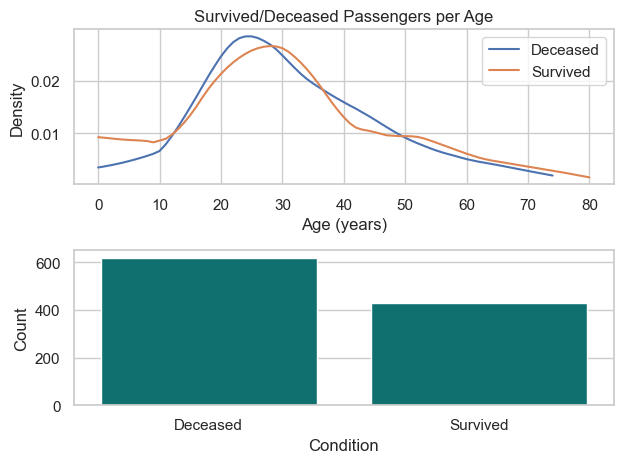

In [605]:
ages_df = df.dropna(subset=["age"])
total_passengers_per_condition = []
conditions = []
for value, group_df in ages_df.groupby("survived"):
    group_df["rounded_age"] = group_df["age"].round()
    age_counts = group_df.groupby("rounded_age")["survived"].count()
    age, count = age_counts.index.to_numpy(), age_counts.to_numpy() 
    counts_normalized = count / sum(count)
    smooth = lowess(counts_normalized, age, frac=0.3, return_sorted=False)
    survived = "Survived" if value else "Deceased" 
    conditions.append(survived)
    total_passengers_per_condition.append(len(group_df))
    plt.subplot(2,1,1)
    sns.lineplot(
        x = age,
        y = smooth,
        label = survived
    )   
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.title("Survived/Deceased Passengers per Age")
plt.legend()

plt.subplot(2,1,2)
amoutns_df = pd.DataFrame({
    "Condition" : conditions,
    "Count" : total_passengers_per_condition
})
sns.barplot(data =amoutns_df, x ="Condition",y="Count", color="teal" )
plt.tight_layout()

plt.show()

Distribution of ages per passenger class

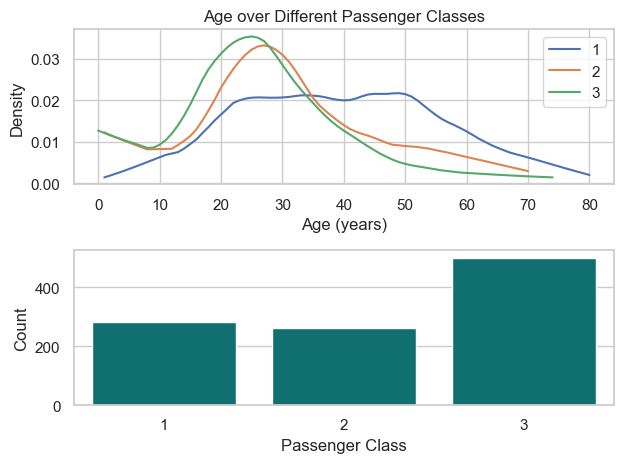

In [606]:
ages_df = df.dropna(subset=["age"])
total_passengers_per_pclass = []
p_classes = []
for value, group_df in ages_df.groupby("pclass"):
    group_df["rounded_age"] = group_df["age"].round()
    age_counts = group_df.groupby("rounded_age")["pclass"].count()
    age, count = age_counts.index.to_numpy(), age_counts.to_numpy() 
    counts_normalized = count / sum(count)
    smooth = lowess(counts_normalized, age, frac=0.3, return_sorted=False)
    p_classes.append(value)
    total_passengers_per_pclass.append(len(group_df))
    plt.subplot(2,1,1)
    sns.lineplot(
        x = age,
        y = smooth,
        label = value
    )   
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.title("Age over Different Passenger Classes")
plt.legend()

plt.subplot(2,1,2)
amoutns_df = pd.DataFrame({
    "Passenger Class" : p_classes,
    "Count" : total_passengers_per_pclass
})
sns.barplot(data =amoutns_df, x ="Passenger Class",y="Count", color="teal" )
plt.tight_layout()

plt.show()

In [607]:
binned_ages_df = ages_df.copy()
binned_ages_df["binned_age"] = pd.cut(df["age"], bins=[5*x for x in range(0,20)], right=False)
ages = []
percentages = []
total_counts = []
for age, group_df in binned_ages_df.groupby("binned_age"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    if total_count > 0: 
        ages.append(str(age))
        percentages.append((survived_count/float(total_count)) * 100)
        total_counts.append(total_count)

binned_ages_df = pd.DataFrame(
    {
        "Age": ages,
        "Survival Percentage" : percentages,
        "Total Count" : total_counts
    }
)


C:\Users\user\AppData\Local\Temp\ipykernel_19244\2513777002.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age, group_df in binned_ages_df.groupby("binned_age"):


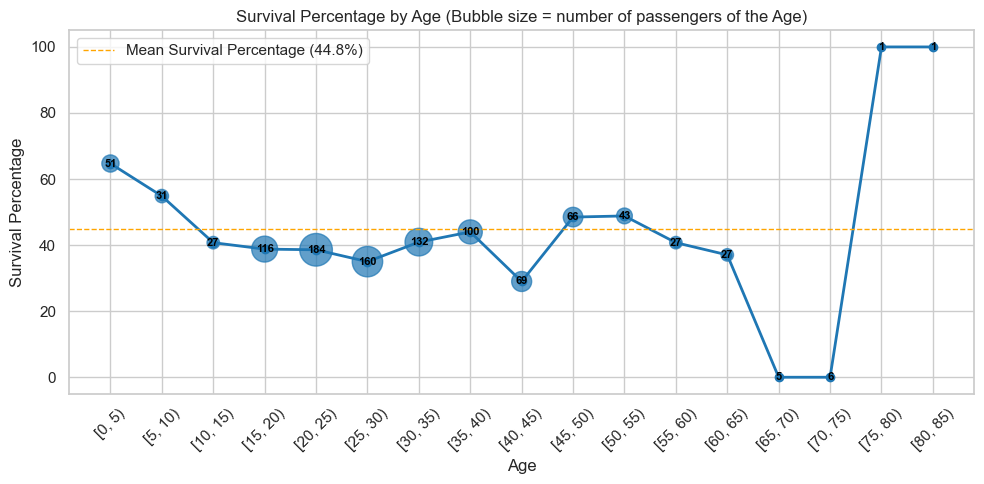

In [608]:
plt.figure(figsize=(10,5))
line_plot_with_bubbles(df = binned_ages_df, x="Age", y="Survival Percentage", z="Total Count")

In [609]:
pclasses = []
percentages = []
total_counts = []
for pclass, group_df in df.groupby("pclass"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    pclasses.append(pclass)
    percentages.append((survived_count/float(total_count)) * 100)
    total_counts.append(total_count)

passenger_class_df = pd.DataFrame(
    {
        "Passenger Class" : pclasses,
        "Survival Percentage" : percentages,
        "Total Count" : total_counts
    }
)



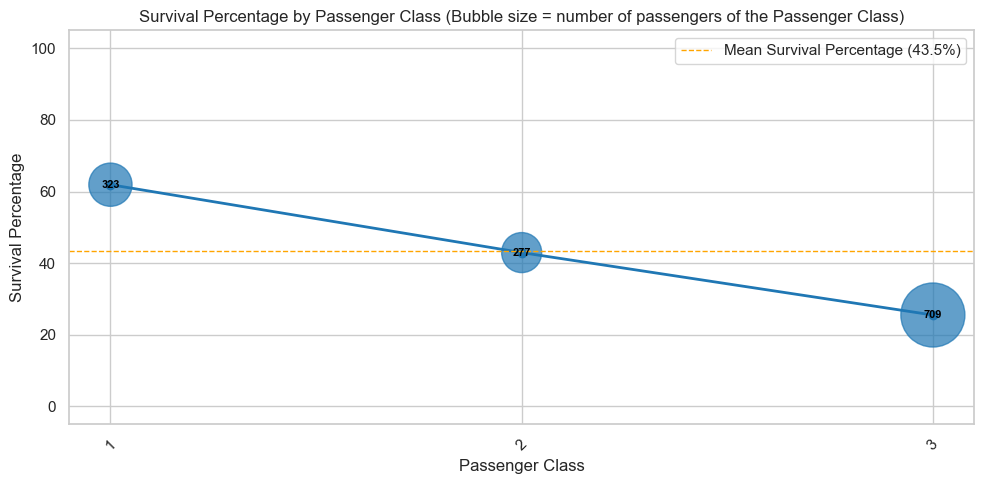

In [610]:
plt.figure(figsize=(10,5))
line_plot_with_bubbles(df=passenger_class_df, x="Passenger Class", y="Survival Percentage", z="Total Count" )

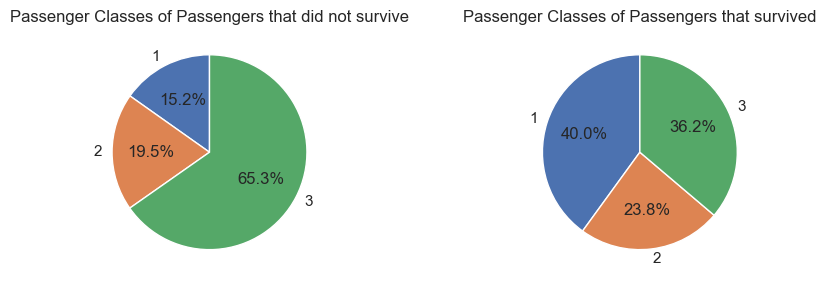

In [611]:
fig = plt.figure(figsize=(10,3))
for i, (survival, group_df) in enumerate(df.groupby("survived")):
    total_number_of_passengers_in_group = len(group_df)
    percentages = []
    pclasses = []
    for pclass, subgroup_df in group_df.groupby("pclass"):
        number_of_passengers_in_pclass = float(len(subgroup_df))
        pclasses.append(pclass)
        percentages.append(number_of_passengers_in_pclass/total_number_of_passengers_in_group)
    fig = plt.subplot(1,2,i+1)
    survived = "survived" if survival else "did not survive"
    fig.set_title(f"Passenger Classes of Passengers that {survived}")
    fig.pie(percentages,labels =pclasses, autopct='%1.1f%%', startangle=90)

plt.tight_layout()
plt.show()


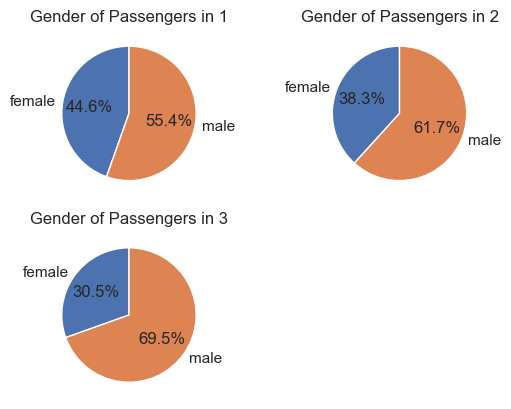

In [612]:
for i, (pclass, group_df) in enumerate(df.groupby("pclass")):
    total_number_of_passengers_in_pclass = len(group_df)
    percentages = []
    genders = []
    for sex, subgroup_df in group_df.groupby("sex"):
        number_of_passengers_in_sex = len(subgroup_df)
        genders.append(sex)
        percentages.append(number_of_passengers_in_sex/float(total_number_of_passengers_in_pclass))
    fig = plt.subplot(2,2,i+1)
    fig.set_title(f"Gender of Passengers in {pclass}")
    fig.pie(percentages,labels =genders, autopct='%1.1f%%', startangle=90)


### Which family had lost the most members?

Families with most losses are: ['Andersson', 'Sage']


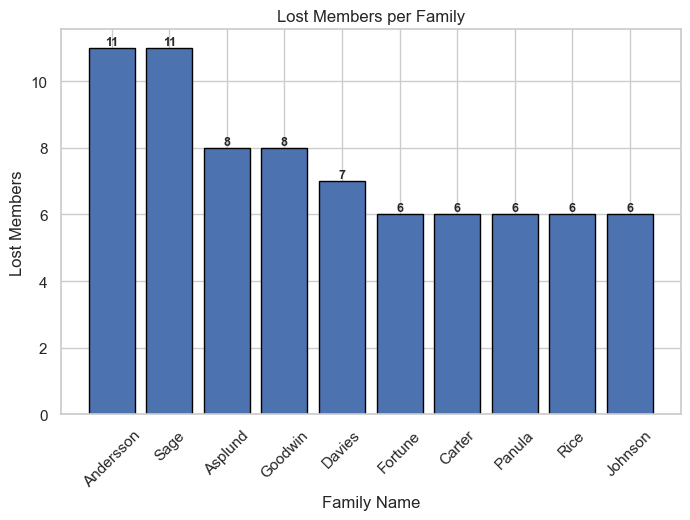

In [621]:
family_df = df.copy()
family_df["name"] = family_df["name"].str.split(",").str[0]
family_df["dead"] = family_df["survived"] == 0
family_df.head()
family_member_loss = family_df.groupby("name")["dead"].count().sort_values(ascending=False)

most_losses = family_member_loss.iloc[0]
most_losses_families = family_member_loss[family_member_loss == most_losses].index
print(f"Families with most losses are: {most_losses_families.tolist()}")

top_k = 10
top_k_family_names = family_member_loss.index.tolist()[:top_k]
top_k_dead_count = family_member_loss.tolist()[:top_k]

plt.figure(figsize=(8,5))
plt.xticks(rotation=45)
bars = plt.bar(top_k_family_names,top_k_dead_count, edgecolor = "black")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x position
        int(height),                           # y position
        f"{height:.0f}",                  # text (formatted)
        ha="center", va="bottom",         # alignment
        fontsize=9, fontweight="bold"
    )

plt.ylabel("Lost Members")
plt.xlabel("Family Name")
plt.title("Lost Members per Family")
plt.show()

### Extras

Per Gender Survival

In [614]:
sexes = []
percentages = []
total_counts = []
for sex, group_df in df.groupby("sex"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    total_counts.append(total_count)
    sexes.append(sex)
    percentages.append((survived_count/float(total_count)) * 100)

gender_df = pd.DataFrame(
    {
        "Gender" : sexes,
        "Survival Percentage" : percentages,
        "Total Count":  total_counts
    }
)

# fig, ax = plt.subplots()
# ax.bar(sexes, [100]*len(sexes), color="#CB0E14", edgecolor = "black")
# green_bar = ax.bar(sexes, percentages, color="#28A728", edgecolor = "black")
# ax.set_ylabel("Survival Percentage (%)")
# ax.set_xlabel("Passenger Gender")
# ax.set_xticks(sexes)
# ax.bar_label(green_bar, fmt='%.2f')
# ax.set_title("Survival Percentage per Gender")

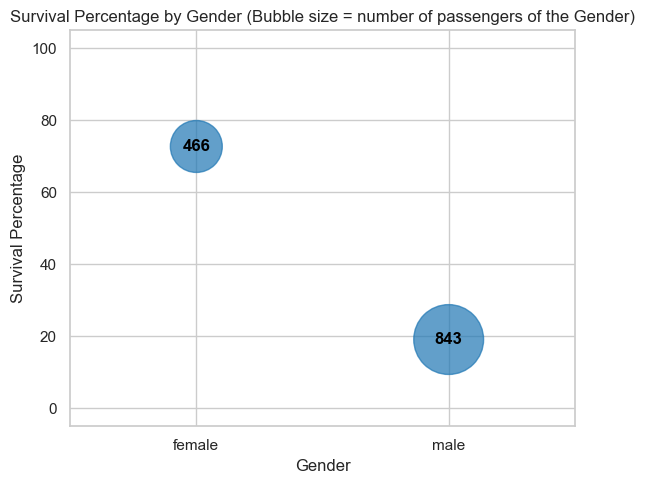

In [615]:
plt.figure(figsize=(6,5))

plt.scatter(
    gender_df["Gender"],
    gender_df["Survival Percentage"],
    s=gender_df["Total Count"] * 3,  
    color="tab:blue",
    alpha=0.7
)


for x_loc, y_loc, count in zip(
    gender_df["Gender"],
    gender_df["Survival Percentage"],
    gender_df["Total Count"]
):
    plt.text(
        x_loc, y_loc,                      
        str(count),                
        ha="center", va="center",  
        fontsize=12, color="black",
        fontweight="bold"
    )


plt.xlabel("Gender")
plt.ylabel("Survival Percentage")
plt.title(f"Survival Percentage by Gender (Bubble size = number of passengers of the Gender)")
plt.grid(True)
plt.ylim(-5,105)
# plt.xticks(gender_df["Gender"], rotation=45)
plt.margins(x=0.5)   # smaller = less empty space around categories
plt.tight_layout()


How did embarked port affect survival rate? 

In [616]:
ports = []
percentages = []
total_counts = []
for port, group_df in df.groupby("embarked"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    total_counts.append(total_count)
    ports.append(port)
    percentages.append((survived_count/float(total_count)) * 100)

embarked_df = pd.DataFrame(
    {
        "Embarked Port" : ports,
        "Survival Percentage" : percentages,
        "Total Count":  total_counts
    }
)

# fig, ax = plt.subplots()
# ax.bar(ports, [100]*len(ports), color="#CB0E14", edgecolor = "black")
# green_bar = ax.bar(ports, percentages, color="#28A728", edgecolor = "black")
# ax.set_ylabel("Survival Percentage (%)")
# ax.set_xlabel("Embarked Port")
# ax.set_xticks(ports)
# ax.bar_label(green_bar, fmt='%.2f')
# ax.set_title("Survival Percentage per Embarked Port")

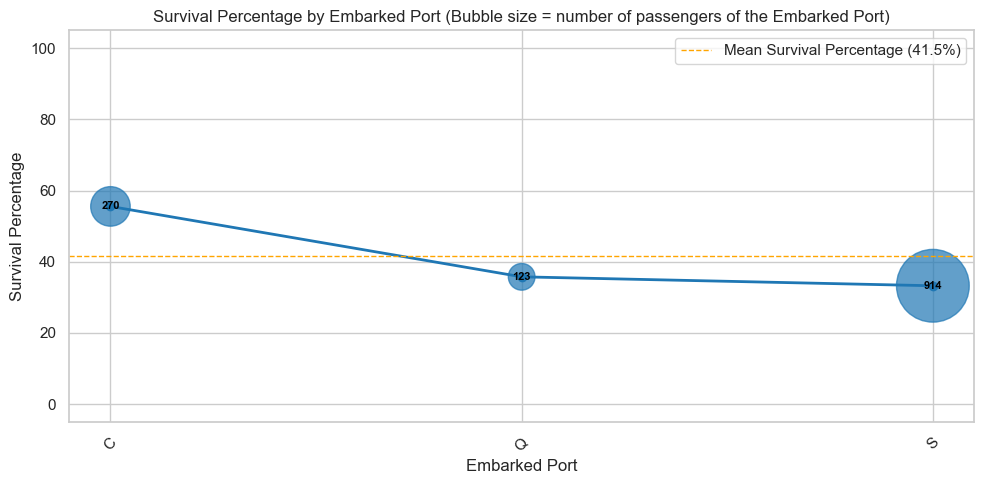

In [617]:
plt.figure(figsize=(10,5))
line_plot_with_bubbles(embarked_df, "Embarked Port", "Survival Percentage", "Total Count")



How many families on board were set appart?